# DBSCAN: Density-Based Spatial Clustering

---

## Intuition

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) discovers clusters of *arbitrary shape* without requiring you to specify the number of clusters $k$ in advance. Instead of partitioning everything, it defines clusters as dense regions of points separated by sparse regions, and automatically labels sparse points as **noise**.

Think of it as finding islands of density in a sea of emptiness.

---

## Key Parameters

- $\varepsilon$ (`eps`): the neighborhood radius. two points are "neighbors" if their distance is $\leq \varepsilon$
- `min_samples`: minimum number of points (including itself) required within distance $\varepsilon$ for a point to be a **core point**

---

## Point Type Definitions

| Point Type | Definition |
|---|---|
| **Core point** | Has $\geq$ `min_samples` neighbors within $\varepsilon$ (including itself) |
| **Border point** | Within $\varepsilon$ of a core point, but is not itself a core point |
| **Noise point** | Not within $\varepsilon$ of any core point; labeled $-1$ |

---

## Algorithm Steps

1. For each unvisited point $p$:
   - If $p$ has $<$ `min_samples` neighbors: mark as noise (tentative)
   - If $p$ has $\geq$ `min_samples` neighbors: start a new cluster, expand via BFS
2. **Expand cluster:** add all density-reachable points to the cluster (BFS through core points)
3. Border points are added to a cluster but do not expand it
4. Points never reached by any core point remain labeled as noise ($-1$)

---

## Advantages and Disadvantages

| | |
|---|---|
| **Advantages** | Finds clusters of arbitrary shape; automatically detects noise/outliers; no need to choose $k$ |
| **Disadvantages** | Struggles with clusters of varying density; sensitive to $\varepsilon$ and `min_samples`; $O(n^2)$ naive complexity (slow on large data) |

---

## Solutions to Common Problems

- **Tuning $\varepsilon$:** plot the sorted $k$-nearest-neighbor distances; the elbow in this curve is a good choice for $\varepsilon$
- **Varying density:** use **HDBSCAN** (hierarchical DBSCAN) which adapts the density threshold per cluster
- **Large datasets:** use ball-tree or kd-tree indexing to speed up neighborhood queries to $O(n \log n)$

---

## Summary: DBSCAN vs $k$-Means

| Property | DBSCAN | $k$-Means |
|---|---|---|
| Choose $k$ in advance? | No | Yes |
| Handles noise/outliers? | Yes (labels $-1$) | No |
| Cluster shape | Arbitrary | Spherical |
| Sensitive to scale? | Yes ($\varepsilon$ is in data units) | Yes (use StandardScaler) |
| Varying density? | Struggles | N/A |
| Speed | $O(n^2)$ naive | $O(nk \cdot \text{iters})$ |

---

**Dataset:** Food Nutrition (`FOOD-DATA-GROUP1.csv`) or synthetic blobs with noise  
**Task:** Find density-based food clusters and identify outliers.

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.unsupervised_learning import DBSCAN, PCA
from rice_ml.preprocess import StandardScaler

In [23]:
try:
    df = pd.read_csv('../../../data/FOOD-DATA-GROUP1.csv')
    num_cols = [c for c in df.select_dtypes(include=np.number).columns
               if 'unnamed' not in c.lower()]
    X = df[num_cols].fillna(0).values.astype(float)
    print(f'Loaded food nutrition dataset (FOOD-DATA-GROUP1): {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import make_blobs
    rng = np.random.default_rng(5)
    X_blobs, _ = make_blobs(n_samples=150, centers=3, n_features=2, random_state=5)
    # Add noise points
    noise = rng.uniform(-10, 10, (20, 2))
    X = np.vstack([X_blobs, noise])
    print('CSV not found. using synthetic blobs with noise')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_2d = PCA(n_components=2).fit_transform(X_scaled)

Loaded food nutrition dataset (FOOD-DATA-GROUP1): (551, 34)


## Dataset Description

**FOOD-DATA-GROUP1.csv** contains **551 food items** described by **37 nutritional features**, including Caloric Value, Fat, Protein, Carbohydrates, Vitamins (A, C, D, B-complex), and Minerals (Iron, Calcium, Potassium, etc.).
[Download from Kaggle](https://www.kaggle.com/datasets/utsavdey1410/food-nutrition-dataset)


This dataset is ideal for DBSCAN because:
- Nutritional profiles form **natural dense regions** (e.g. dairy products cluster together, meats cluster together)
- Some foods are **nutritional outliers** (e.g. exotic items with unusual macro ratios) that DBSCAN will flag as noise
- The clusters are not necessarily spherical in high-dimensional space

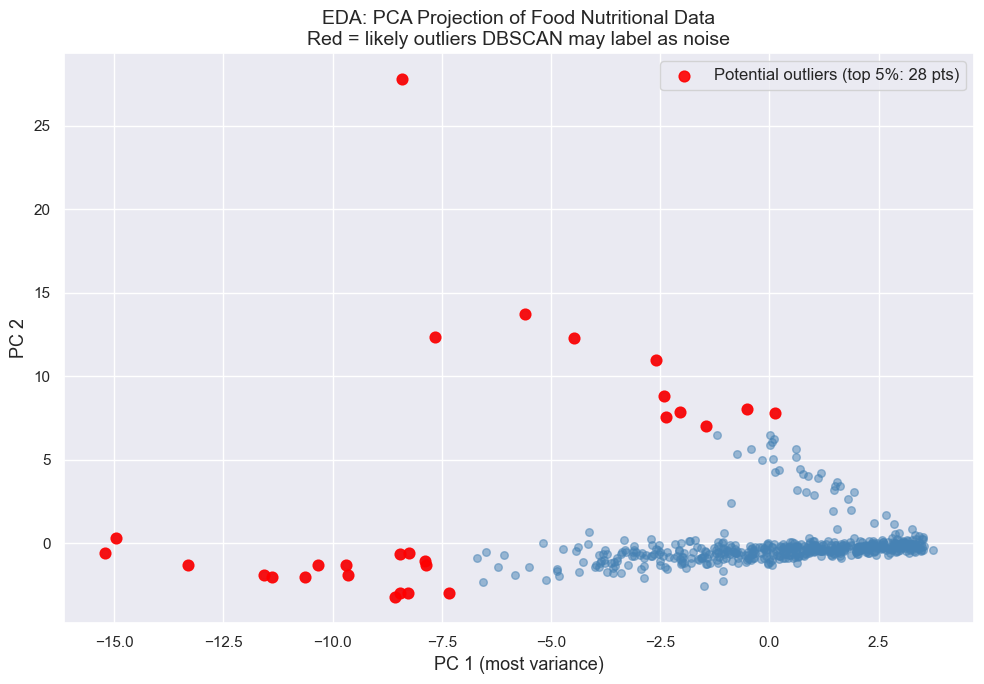

Total foods: 551
Potential outliers (top 5% by PCA distance): 28
These extreme foods may have unusual nutritional profiles.


In [24]:
# --- EDA: PCA projection to visualize data structure before clustering ---
# The first 2 PCA dimensions capture the most variance.
# Points far from the main mass are likely nutritional outliers.
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, color='steelblue', s=30)

# Highlight potential outliers: points more than 3 std from origin in PCA space
dist_from_origin = np.linalg.norm(X_2d, axis=1)
outlier_thresh = np.percentile(dist_from_origin, 95)
outlier_mask = dist_from_origin > outlier_thresh
ax.scatter(X_2d[outlier_mask, 0], X_2d[outlier_mask, 1],
           color='red', s=60, alpha=0.9, label=f'Potential outliers (top 5%: {outlier_mask.sum()} pts)')

ax.set_xlabel('PC 1 (most variance)', fontsize=13)
ax.set_ylabel('PC 2', fontsize=13)
ax.set_title('EDA: PCA Projection of Food Nutritional Data\nRed = likely outliers DBSCAN may label as noise', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'Total foods: {len(X_2d)}')
print(f'Potential outliers (top 5% by PCA distance): {outlier_mask.sum()}')
print('These extreme foods may have unusual nutritional profiles.')

## DBSCAN Point Types: Illustrated

The diagram below shows the three point types on a small toy dataset. The circles represent the $\varepsilon$-neighborhood of selected points.

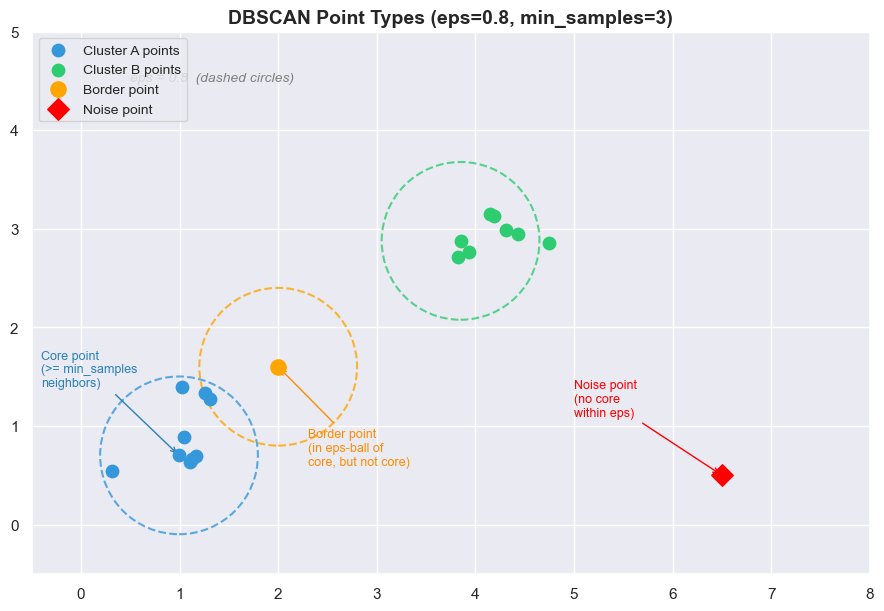

In [25]:
# --- Diagram: DBSCAN point types ---
rng_d = np.random.default_rng(42)

# Dense cluster A
clA = rng_d.normal([1, 1], 0.35, (9, 2))
# Dense cluster B
clB = rng_d.normal([4, 3], 0.35, (8, 2))
# A border point near cluster A
border_pt = np.array([[2.0, 1.6]])
# A noise point isolated
noise_pt = np.array([[6.5, 0.5]])

all_pts = np.vstack([clA, clB, border_pt, noise_pt])

eps_val = 0.8
min_s = 3

fig, ax = plt.subplots(figsize=(9, 7))

# Plot cluster A points
ax.scatter(clA[:, 0], clA[:, 1], c='#3498db', s=80, zorder=4, label='Cluster A points')
# Plot cluster B points
ax.scatter(clB[:, 0], clB[:, 1], c='#2ecc71', s=80, zorder=4, label='Cluster B points')
# Border point
ax.scatter(border_pt[:, 0], border_pt[:, 1], c='orange', s=120, zorder=5, label='Border point')
# Noise point
ax.scatter(noise_pt[:, 0], noise_pt[:, 1], c='red', s=120, marker='D', zorder=5, label='Noise point')

# Draw eps-circle around a core point in cluster A
core_A = clA[4]
circle_A = plt.Circle(core_A, eps_val, color='#3498db', fill=False,
                       linestyle='--', linewidth=1.5, alpha=0.8)
ax.add_patch(circle_A)
ax.annotate('Core point\n(>= min_samples\nneighbors)', xy=core_A,
            xytext=(core_A[0]-1.4, core_A[1]+0.7),
            fontsize=9, color='#2980b9',
            arrowprops=dict(arrowstyle='->', color='#2980b9'))

# Draw eps-circle around a core point in cluster B
core_B = clB[3]
circle_B = plt.Circle(core_B, eps_val, color='#2ecc71', fill=False,
                       linestyle='--', linewidth=1.5, alpha=0.8)
ax.add_patch(circle_B)

# Draw eps-circle around the border point
circle_border = plt.Circle(border_pt[0], eps_val, color='orange', fill=False,
                            linestyle='--', linewidth=1.5, alpha=0.8)
ax.add_patch(circle_border)
ax.annotate('Border point\n(in eps-ball of\ncore, but not core)', xy=border_pt[0],
            xytext=(border_pt[0][0]+0.3, border_pt[0][1]-1.0),
            fontsize=9, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange'))

# Annotate noise
ax.annotate('Noise point\n(no core\nwithin eps)', xy=noise_pt[0],
            xytext=(noise_pt[0][0]-1.5, noise_pt[0][1]+0.6),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlim(-0.5, 8)
ax.set_ylim(-0.5, 5)
ax.set_aspect('equal')
ax.set_title(f'DBSCAN Point Types (eps={eps_val}, min_samples={min_s})', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.text(0.5, 4.5, f'eps = {eps_val}  (dashed circles)', fontsize=10, style='italic', color='gray')
plt.tight_layout()
plt.show()

## Fit DBSCAN

## Scaling and eps Selection

Scaling is critical for DBSCAN. The eps parameter is a distance threshold in the scaled feature space. After StandardScaler, each feature has mean 0 and standard deviation 1, so distances are on a comparable scale across all 36 nutritional dimensions.

In 36-dimensional space, even scaled data spreads out: the median nearest-neighbor distance is around 1.2, so eps must be set in that range. An eps of 0.5 is too small and labels everything as noise. Setting eps near 2.0 identifies meaningful dense clusters while still flagging true nutritional outliers.

Rule of thumb: use a k-distance plot (sort the distance to the k-th neighbor for all points) to find the elbow, which gives a principled choice for eps.

In [26]:
db = DBSCAN(eps=2.0, min_samples=5)
labels = db.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))

print(f'Clusters found: {n_clusters}')
print(f'Noise points:   {n_noise} ({100*n_noise/len(labels):.1f}%)')

Clusters found: 4
Noise points:   286 (51.9%)


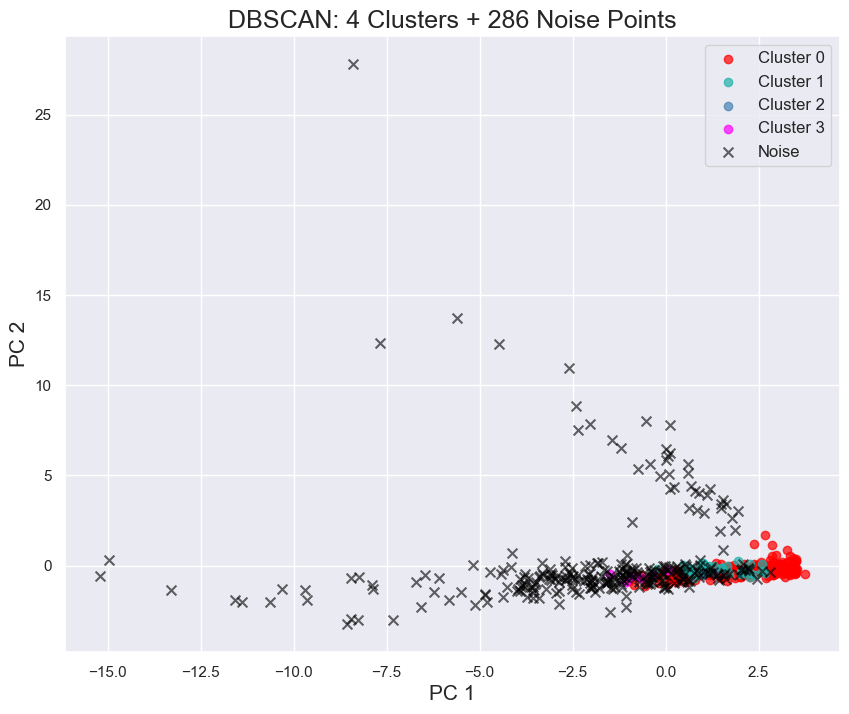

In [27]:
colors = ['red', 'lightseagreen', 'steelblue', 'magenta', 'orange',
          'purple', 'brown', 'pink', 'cyan', 'lime']

plt.figure(figsize=(10, 8))
unique_labels = set(labels)
for lbl in unique_labels:
    mask = labels == lbl
    if lbl == -1:
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c='black', marker='x', s=50, label='Noise', alpha=0.6)
    else:
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=colors[lbl % len(colors)], label=f'Cluster {lbl}', alpha=0.7)

plt.xlabel('PC 1', fontsize=15)
plt.ylabel('PC 2', fontsize=15)
plt.title(f'DBSCAN: {n_clusters} Clusters + {n_noise} Noise Points', fontsize=18)
plt.legend(fontsize=12)
plt.show()

## Effect of `eps` on Clustering

Smaller `eps` means a tighter neighborhood requirement, so more points become noise. Larger `eps` merges clusters together. Choosing `eps` is the most important hyperparameter decision in DBSCAN.

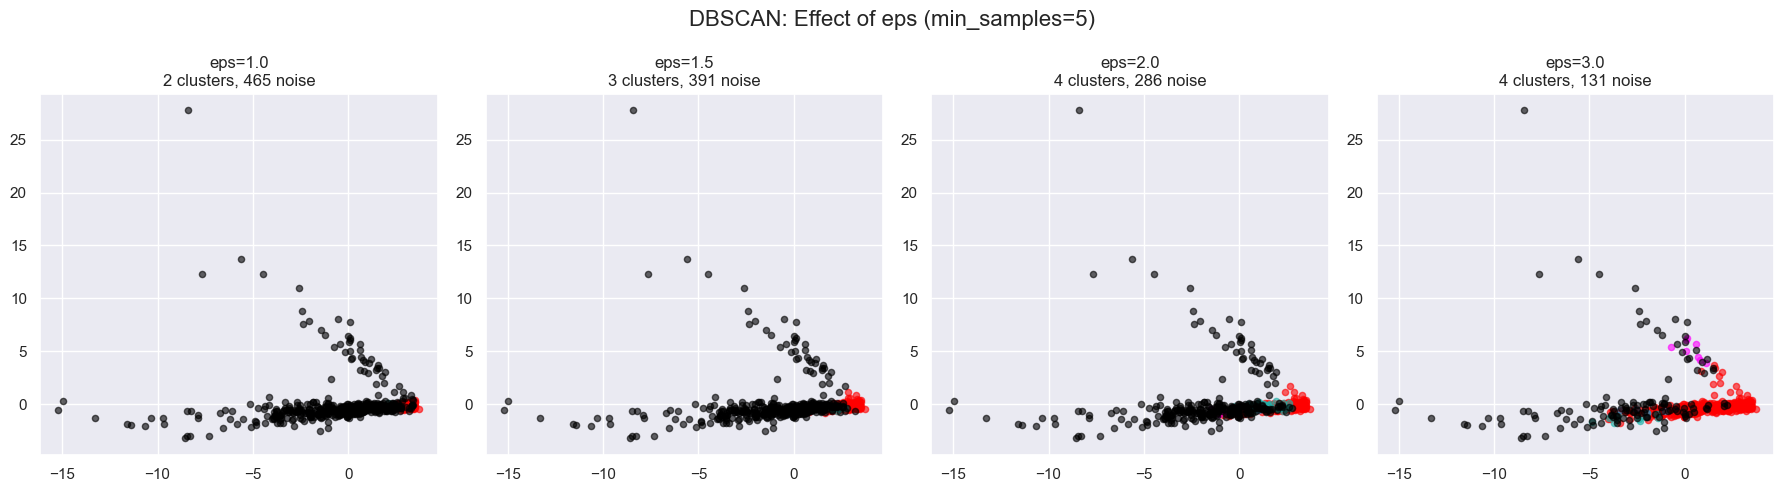

In [28]:
eps_values = [1.0, 1.5, 2.0, 3.0]
fig, axes = plt.subplots(1, len(eps_values), figsize=(18, 5))

for ax, eps in zip(axes, eps_values):
    lbs = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    n_c = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_n = int(np.sum(lbs == -1))
    for lbl in set(lbs):
        mask = lbs == lbl
        color = 'black' if lbl == -1 else colors[lbl % len(colors)]
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.6, s=20)
    ax.set_title(f'eps={eps}\n{n_c} clusters, {n_n} noise', fontsize=12)

plt.suptitle('DBSCAN: Effect of eps (min_samples=5)', fontsize=16)
plt.tight_layout()
plt.show()

## Interpretation

- DBSCAN finds clusters of **arbitrary shape**: unlike $k$-Means which assumes spheres, DBSCAN can find elongated, curved, or ring-shaped clusters.
- Noise points (labeled $-1$) are outliers not belonging to any dense region. in food data, these are nutritionally extreme items (e.g. pure fats, pure sugars).
- `eps` and `min_samples` must be tuned together: use a **$k$-distance plot** (sort the distance to the $k$-th neighbor for all points) to choose `eps` as the distance at the elbow.
- For the food dataset, noise points often represent specialty or processed foods with atypical nutritional profiles. DBSCAN's noise detection is valuable for anomaly identification.
- When density varies between clusters (e.g. one tight cluster and one spread-out cluster), DBSCAN may split the sparse cluster into noise. consider HDBSCAN in that case.